In [1]:
import numpy as np
import pandas as pd

# give you file path here
dataset = pd.read_csv('/content/heart.csv')

dataset.head()

,age,cholesterol,blood_pressure,max_heart_rate,target
0,68,270,126,122,0
1,58,182,168,132,0
2,44,299,133,183,0
3,72,170,104,178,0
4,37,219,132,180,0


In [2]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             1000 non-null   int64
 1   cholesterol     1000 non-null   int64
 2   blood_pressure  1000 non-null   int64
 3   max_heart_rate  1000 non-null   int64
 4   target          1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [3]:
print(dataset.isnull().sum())
print(dataset.describe())

age               0
cholesterol       0
blood_pressure    0
max_heart_rate    0
target            0
dtype: int64
               age  cholesterol  blood_pressure  max_heart_rate      target
count  1000.000000  1000.000000     1000.000000     1000.000000  1000.00000
mean     54.830000   222.682000      132.666000      125.163000     0.32800
std      14.346809    43.648139       26.285002       36.879242     0.46972
min      30.000000   150.000000       90.000000       60.000000     0.00000
25%      43.000000   186.000000      110.000000       94.000000     0.00000
50%      55.000000   221.500000      131.000000      125.000000     0.00000
75%      66.000000   260.000000      156.000000      158.000000     1.00000
max      79.000000   299.000000      179.000000      189.000000     1.00000


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             1000 non-null   int64
 1   cholesterol     1000 non-null   int64
 2   blood_pressure  1000 non-null   int64
 3   max_heart_rate  1000 non-null   int64
 4   target          1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


target
0    672
1    328
Name: count, dtype: int64


/tmp/ipykernel_3124/2356728308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=dataset, palette='coolwarm')


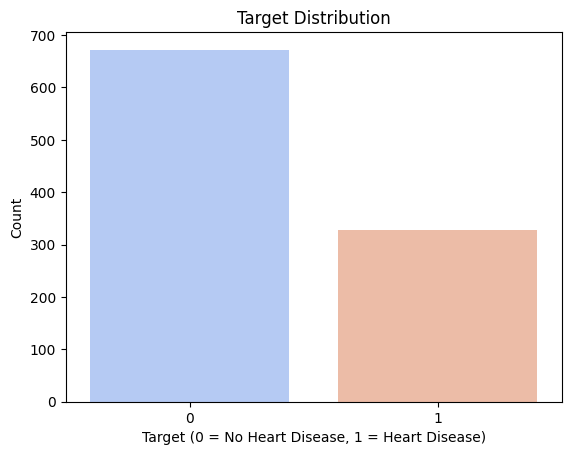

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

print(dataset['target'].value_counts())

sns.countplot(x='target', data=dataset, palette='coolwarm')

plt.title('Target Distribution')
plt.xlabel('Target (0 = No Heart Disease, 1 = Heart Disease)')
plt.ylabel('Count')

plt.show()

In [7]:
dataset['cholesterol'] = pd.to_numeric(dataset['cholesterol'], errors='coerce')
dataset['cholesterol'].fillna(dataset['cholesterol'].median(), inplace=True)

/tmp/ipykernel_3124/2463421646.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['cholesterol'].fillna(dataset['cholesterol'].median(), inplace=True)


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             1000 non-null   int64
 1   cholesterol     1000 non-null   int64
 2   blood_pressure  1000 non-null   int64
 3   max_heart_rate  1000 non-null   int64
 4   target          1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [9]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

categorical_cols = ['target']

for col in categorical_cols:
    dataset[col] = labelencoder.fit_transform(dataset[col])

In [10]:
from sklearn.model_selection import train_test_split

X = dataset.drop('target', axis=1)
y = dataset['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.81
